# Analisis de sentimientos en Twitter
### Autor: Diego Castro Satt

In [44]:
#importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [45]:
df = pd.read_csv('twitter_training.csv')
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [46]:
df.columns = ["id","topic","sentiment","text"]
df.columns


Index(['id', 'topic', 'sentiment', 'text'], dtype='str')

In [47]:
labels = {
    "Negative":0,
    "Neutral":1,
    "Positive":2,
    "Irrelevant":3
}
df["label"] = df["sentiment"].map(labels)

In [48]:
df["text"] = df["text"].str.strip()
df["text"] = df["text"].str.lower()
df = df[df["text"].str.len() > 0]
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print(df[["text_length", "word_count"]].describe())

        text_length    word_count
count  73823.000000  73823.000000
mean     108.936713     19.271528
std       79.469904     14.429567
min        1.000000      1.000000
25%       47.000000      8.000000
50%       91.000000     16.000000
75%      153.000000     27.000000
max      957.000000    198.000000


## EDA

In [49]:
df.info()

<class 'pandas.DataFrame'>
Index: 73823 entries, 0 to 74680
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           73823 non-null  int64
 1   topic        73823 non-null  str  
 2   sentiment    73823 non-null  str  
 3   text         73823 non-null  str  
 4   label        73823 non-null  int64
 5   text_length  73823 non-null  int64
 6   word_count   73823 non-null  int64
dtypes: int64(4), str(3)
memory usage: 4.5 MB


In [50]:
df.describe()

,id,label,text_length,word_count
count,73823.000000,73823.000000,73823.000000,73823.000000
mean,6429.654241,1.324966,108.936713,19.271528
std,3736.773064,1.082481,79.469904,14.429567
min,1.000000,0.000000,1.000000,1.000000
25%,3194.000000,0.000000,47.000000,8.000000
50%,6416.000000,1.000000,91.000000,16.000000
75%,9593.000000,2.000000,153.000000,27.000000
max,13200.000000,3.000000,957.000000,198.000000


In [51]:
df.isnull().sum()

id             0
topic          0
sentiment      0
text           0
label          0
text_length    0
word_count     0
dtype: int64

In [52]:
df.dropna(inplace=True) # Eliminar filas con valores nulos

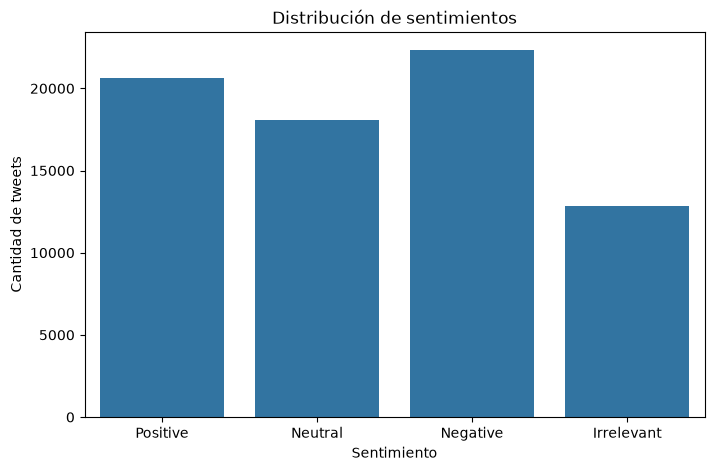

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="sentiment")
plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")
plt.show()

In [54]:
# porcentaje de cada sentimiento en el conjunto de entrenamiento
df["sentiment"].value_counts(normalize=True)*100

sentiment
Negative      30.223643
Positive      27.928965
Neutral       24.451729
Irrelevant    17.395663
Name: proportion, dtype: float64

### Los temas mas frecuentes

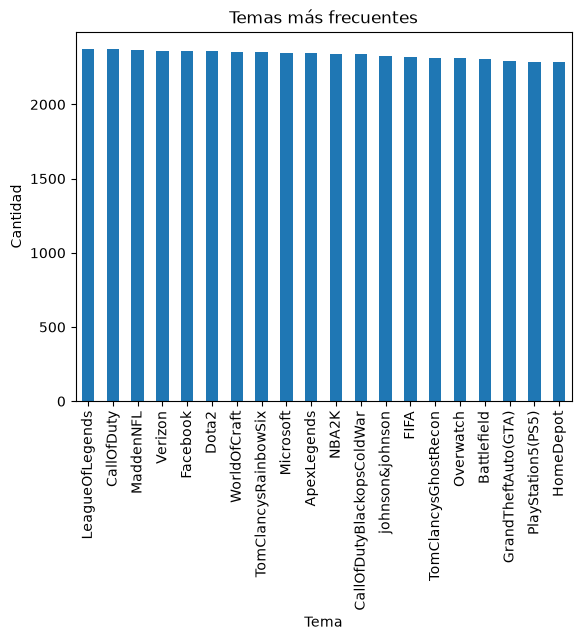

In [55]:
df["topic"].value_counts().head(20).sort_values(ascending=False).plot(kind="bar") 
plt.title("Temas más frecuentes") 
plt.xlabel("Tema")
plt.ylabel("Cantidad");
plt.xticks(rotation=90)
plt.show()

### Longitud de tweets

In [56]:
df["text_length"] = (
    df["text"]
    .astype(str)
    .apply(len)
)


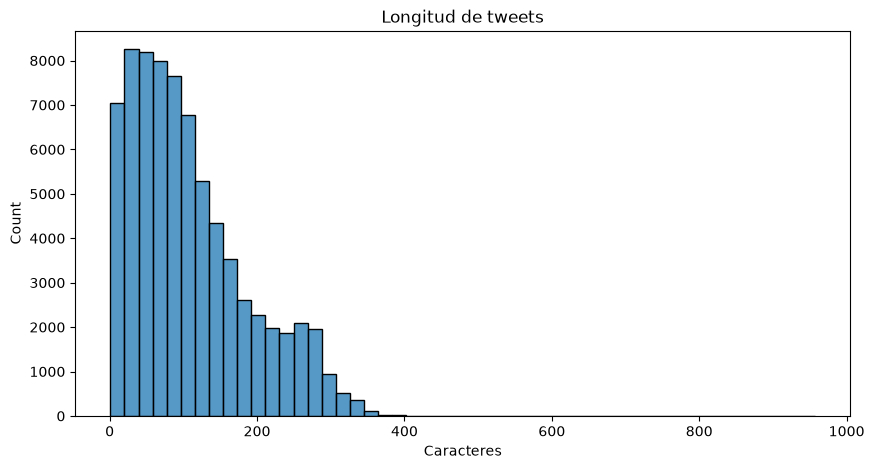

In [57]:
plt.figure(figsize=(10,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Longitud de tweets")
plt.xlabel("Caracteres")
plt.show()

In [58]:
# Cantidad de palabras por tweet en el conjunto de entrenamiento
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df[["text", "word_count"]].head()

,text,word_count
0,i am coming to the borders and i will kill you...,12
1,im getting on borderlands and i will kill you ...,10
2,im coming on borderlands and i will murder you...,10
3,im getting on borderlands 2 and i will murder ...,12
4,im getting into borderlands and i can murder y...,10


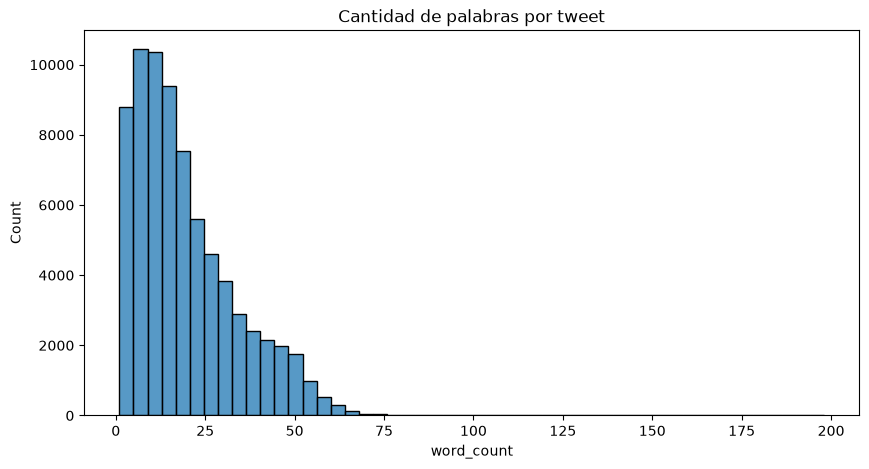

In [59]:
plt.figure(figsize=(10,5))
sns.histplot(df["word_count"], bins=50)
plt.title("Cantidad de palabras por tweet")
plt.show()

### Palabras más frecuentes

In [60]:
all_words = " ".join(df["text"].astype(str))
words = all_words.split()
frequency = Counter(words)
frequency.most_common(20)

[('the', 44099),
 ('i', 28915),
 ('to', 28652),
 ('and', 26321),
 ('a', 23925),
 ('of', 19307),
 ('is', 17453),
 ('for', 15410),
 ('in', 15046),
 ('/', 14655),
 ('this', 13708),
 ('my', 11767),
 ('on', 11591),
 ('it', 11413),
 ('you', 11272),
 ('@', 11081),
 ('.', 10201),
 ('that', 9705),
 ('with', 8714),
 ('so', 7593)]

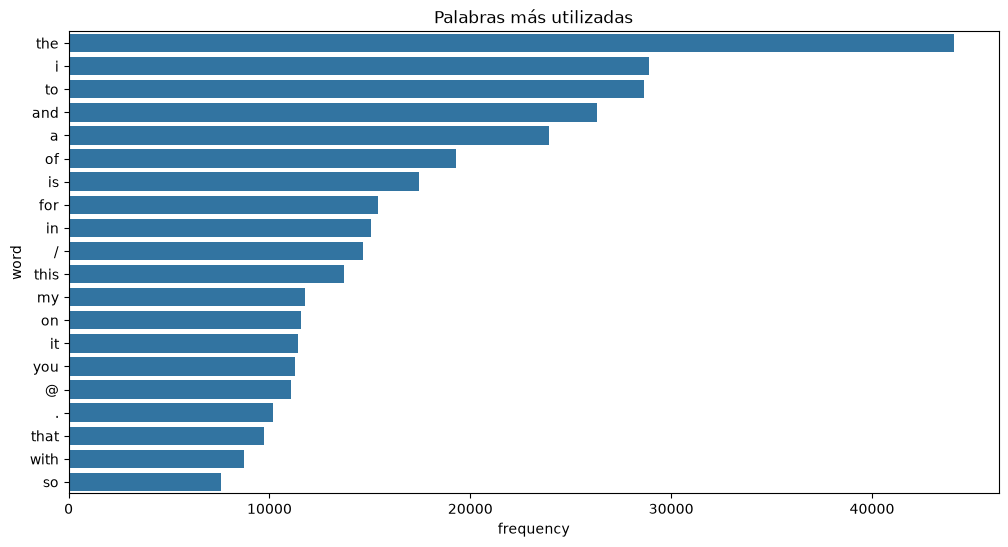

In [61]:
common_words = pd.DataFrame(frequency.most_common(20), columns=["word", "frequency"])
plt.figure(figsize=(12,6))
sns.barplot(data=common_words, x="frequency", y="word")
plt.title("Palabras más utilizadas")
plt.show()

In [62]:
label_map = {"Negative":0, "Neutral":1, "Positive":2, "Irrelevant":3}
df["label"] = df["sentiment"].map(label_map)
df.head()

,id,topic,sentiment,text,label,text_length,word_count
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,2,51,12
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,2,50,10
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,2,51,10
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,2,57,12
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,2,53,10


## Token 

In [63]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [64]:
texto = "I love this game"
tokens = tokenizer(texto, padding=True, truncation=True, return_tensors="pt")
tokens

{'input_ids': tensor([[ 101, 1045, 2293, 2023, 2208,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

## Dataset


In [108]:
class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("label", axis=1), df["label"], test_size=0.2, stratify=df["label"], random_state=42)


In [67]:
train_dataset = TwitterDataset(X_train, y_train, tokenizer)
test_dataset = TwitterDataset(X_test, y_test, tokenizer)

In [112]:

label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
    "Irrelevant": 3
}

id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    label2id=label2id,
    id2label=id2label
)
TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none"
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, average="weighted"),
        "recall": recall_score(labels, predictions, average="weighted"),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [70]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [71]:

indices = np.random.choice(len(test_dataset), 1000, replace=False)
test_subset = Subset(test_dataset, indices)

results = trainer.predict(test_dataset)
y_pred = np.argmax(results.predictions, axis=1)

results = trainer.predict(test_subset)
y_true = y_test[test_subset.indices]



In [72]:
print(len(y_true), len(y_pred))

1000 14765


In [83]:
print(np.unique(y_test, return_counts=True))
print(np.unique(y_pred, return_counts=True))

(array([0, 1, 2, 3]), array([324, 238, 267, 171]))
(array([0, 2, 3]), array([ 11,  35, 954]))


In [88]:
results = trainer.predict(test_subset)
y_pred = np.argmax(results.predictions, axis=1)
y_test = [test_subset.dataset.labels[i] for i in test_subset.indices]
print(len(y_test))
print(len(y_pred))

1000
1000


In [85]:
print(classification_report(
    y_true,
    y_pred,
    labels=[0,1,2,3],
    target_names=["Negative", "Neutral", "Positive", "Irrelevant"],
    zero_division=0
))

              precision    recall  f1-score   support

    Negative       0.18      0.01      0.01       324
     Neutral       0.00      0.00      0.00       238
    Positive       0.09      0.01      0.02       267
  Irrelevant       0.17      0.97      0.30       171

    accuracy                           0.17      1000
   macro avg       0.11      0.25      0.08      1000
weighted avg       0.11      0.17      0.06      1000



In [86]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.171
Precision: 0.11154952217593729
Recall: 0.171
F1: 0.05963729247800731


In [92]:
df['sentiment'].value_counts()

sentiment
Negative      22312
Positive      20618
Neutral       18051
Irrelevant    12842
Name: count, dtype: int64

In [107]:
from collections import Counter

print(Counter(y_pred))

Counter({3: 14045, 2: 589, 0: 130, 1: 1})


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive", "Irrelevant"]
)

disp.plot(cmap="Blues")
plt.show()

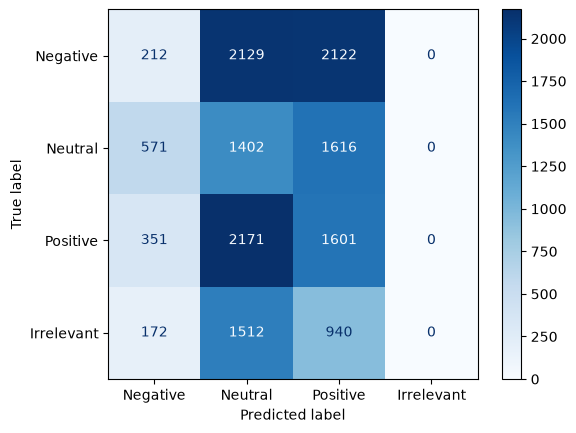

## Predicción de tweets

In [77]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [78]:
print(next(model.parameters()).device)
print(device)

mps:0
mps


In [105]:
def predecir_sentimiento(texto):
    model.eval()
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probabilidades = torch.softmax(outputs.logits, dim=1)
    pred = outputs.logits.argmax(dim=1).item()
    traduccion = {
        "LABEL_0": "Negative",
        "LABEL_1": "Neutral",
        "LABEL_2": "Positive",
        "LABEL_3": "Irrelevant"
    }

    etiqueta_modelo = model.config.id2label[pred]
    sentimiento = traduccion.get(etiqueta_modelo, etiqueta_modelo)

    print(f"Texto: {texto}")
    print(f"Sentimiento: {sentimiento}")
    print(f"Confianza: {probabilidades[0][pred].item()*100:.2f}%")

Pruebas

In [80]:
predecir_sentimiento("I have been playing this game for several months and I really wanted to enjoy it because the graphics are amazing and the gameplay has a lot of potential. However, after the latest update, the experience has become frustrating. The servers disconnect frequently, matchmaking takes too long, and there are several bugs that make missions impossible to complete. Customer support has not responded to my requests, which makes the situation even worse. Although I still think the game has a great concept and I appreciate the effort of the developers, at the moment I cannot recommend it to anyone until these issues are fixed.")

Texto: I have been playing this game for several months and I really wanted to enjoy it because the graphics are amazing and the gameplay has a lot of potential. However, after the latest update, the experience has become frustrating. The servers disconnect frequently, matchmaking takes too long, and there are several bugs that make missions impossible to complete. Customer support has not responded to my requests, which makes the situation even worse. Although I still think the game has a great concept and I appreciate the effort of the developers, at the moment I cannot recommend it to anyone until these issues are fixed.
Sentimiento: Irrelevant
Confianza: 27.34%


In [81]:
predecir_sentimiento("I was really excited to try this game after reading so many positive reviews, but it ended up being a huge disappointment. The performance is terrible, with constant lag and crashes, the controls feel unresponsive, and the missions quickly become repetitive. On top of that, the game is filled with expensive microtransactions that make progression frustrating unless you spend money. I regret buying it and I don't think I'll be playing it again unless major improvements are made.")

Texto: I was really excited to try this game after reading so many positive reviews, but it ended up being a huge disappointment. The performance is terrible, with constant lag and crashes, the controls feel unresponsive, and the missions quickly become repetitive. On top of that, the game is filled with expensive microtransactions that make progression frustrating unless you spend money. I regret buying it and I don't think I'll be playing it again unless major improvements are made.
Sentimiento: Irrelevant
Confianza: 26.90%
